# Analisis Sentimen Review Produk Olahraga Menggunakan IndoBERT
**Deskripsi Proyek:** Proyek ini bertujuan membangun model Sentiment Analysis pada ulasan produk kategori olahraga menggunakan model IndoBERT (indobenchmark/indobert-base-p1) untuk mengklasifikasikan sentimen menjadi tiga kelas, yaitu positif, netral, dan negatif. Tahapan yang dilakukan meliputi Exploratory Data Analysis (EDA), preprocessing teks tanpa menggunakan Sastrawi, pelabelan menggunakan target asli dataset, tokenisasi, pelatihan model menggunakan class weight, evaluasi performa menggunakan Accuracy, Macro F1, Weighted F1, Error Analysis, Inference, serta penyimpanan model ke format .pkl. Model terbaik menggunakan konfigurasi learning rate 1e-5, batch size 16, epoch 6, dan warmup step 100 dengan hasil Accuracy sebesar 87,29%, Macro F1 sebesar 63,04%, dan Weighted F1 sebesar 88,49%.

# A. Import Library

In [1]:
!pip install pandas numpy scikit-learn transformers torch accelerate matplotlib -q

import pandas as pd
import numpy as np
import re
import os
import ast
import pickle
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import html

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# B. Load Data Scraping

In [2]:
base_path = "/kaggle/input/datasets/adindaintanerlita/sentiment-olahraga/"

df = pd.read_csv(
    base_path + "olahraga.csv"
)

with open(
    base_path + "slangwords.csv",
    "r",
    encoding="utf-8"
) as f:

    slang_dict = ast.literal_eval(
        f.read()
    )

print(df.head())

print(
    "Jumlah data:",
    len(df)
)

print(df.info())

print(
    df.isnull().sum()
)

                                                name  category  \
0  Deker / Dekker Lutut / Knee Support LP 758 Ope...  olahraga   
1  Cover Bat / Bet Pingpong / Tenis Meja Butterfl...  olahraga   
2  Baju Sauna / Sauna Suit Kettler Abu Tua - Abu ...  olahraga   
3  Deker / Dekker Lutut / Knee Support Open Patel...  olahraga   
4  Baju Sauna / Sauna Suit Kettler Abu Tua - Abu ...  olahraga   

                                              review  rating    target  
0                 Thnks...........................:)       3   Neutral  
1  bagus pemesanan sesuai yang diorder dan tepat ...       4  Positive  
2        Bahannya bagus... Semoga hasilnya juga OK..       4  Positive  
3      Kiriman baramg cepat dan barang kondisi bagus       3   Neutral  
4  Siiiip...barang bagus sesuai deskripsi . Ini u...       5  Positive  
Jumlah data: 10000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
-

# C. Exploratory Data Analysis (EDA)

Ukuran dataset: (10000, 5)

Nama kolom:
Index(['name', 'category', 'review', 'rating', 'target'], dtype='object')

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      10000 non-null  object
 1   category  10000 non-null  object
 2   review    10000 non-null  object
 3   rating    10000 non-null  int64 
 4   target    10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None

Missing value:
name        0
category    0
review      0
rating      0
target      0
dtype: int64

Duplikasi:
0

Distribusi rating:
rating
1     225
2     147
3     709
4    2134
5    6785
Name: count, dtype: int64

Distribusi target:
target
Positive    8919
Neutral      709
Negative     372
Name: count, dtype: int64
       review_length    word_count
count   10000.000000  10000.000000
mean       65.210300      9.432700
std        87.92

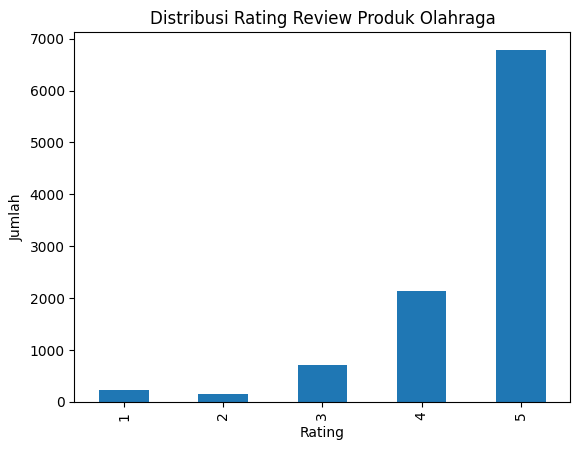

In [3]:
print("Ukuran dataset:", df.shape)

print("\nNama kolom:")
print(df.columns)

print("\nInfo dataset:")
print(df.info())

print("\nMissing value:")
print(df.isnull().sum())

print("\nDuplikasi:")
print(df.duplicated().sum())

print("\nDistribusi rating:")
print(df["rating"].value_counts().sort_index())

if "target" in df.columns:

    print("\nDistribusi target:")

    print(
        df["target"]
        .value_counts()
    )

df["review_length"] = (
    df["review"]
    .astype(str)
    .apply(len)
)

df["word_count"] = (
    df["review"]
    .astype(str)
    .apply(
        lambda x:
        len(x.split())
    )
)

print(
    df[
        [
            "review_length",
            "word_count"
        ]
    ].describe()
)

df[
    "rating"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Distribusi Rating Review Produk Olahraga"
)

plt.xlabel("Rating")

plt.ylabel("Jumlah")

plt.show()

# D. Preprocessing

In [4]:
emoji_dict = {
    "😊": "senang",
    "😁": "senang",
    "😍": "suka",
    "🥰": "suka",
    "😭": "kecewa",
    "😢": "sedih",
    "😡": "marah",
    "😤": "kesal",
    "🤩": "senang",
    "🔥": "bagus",
    "👍": "bagus",
    "👎": "jelek",
    "💔": "kecewa",
    "❤️": "suka",
    "❤": "suka"
}

def clean_text(text):

    text = str(text).lower()

    text = html.unescape(text)

    text = re.sub(
        r'\\n|\\t|\\r|\\b|\\f|\\v',
        ' ',
        text
    )

    text = re.sub(
        r'\\u[0-9a-fA-F]{4}',
        ' ',
        text
    )

    text = re.sub(
        r'\\x[0-9a-fA-F]{2}',
        ' ',
        text
    )

    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    for emo, meaning in emoji_dict.items():

        text = text.replace(
            emo,
            " " + meaning + " "
        )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    words = text.split()

    words = [
        slang_dict.get(
            w,
            w
        )

        for w in words
    ]

    text = " ".join(words)

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

df = df.dropna(
    subset=["review"]
)

df["clean_text"] = (
    df["review"]
    .apply(clean_text)
)

df = df[
    df["clean_text"] != ""
]

print(
    df[
        [
            "review",
            "clean_text",
            "rating"
        ]
    ].head()
)

                                              review  \
0                 Thnks...........................:)   
1  bagus pemesanan sesuai yang diorder dan tepat ...   
2        Bahannya bagus... Semoga hasilnya juga OK..   
3      Kiriman baramg cepat dan barang kondisi bagus   
4  Siiiip...barang bagus sesuai deskripsi . Ini u...   

                                          clean_text  rating  
0                                              thnks       3  
1  bagus pemesanan sesuai yang diorder dan tepat ...       4  
2            bahannya bagus semoga hasilnya juga oke       4  
3      kiriman baramg cepat dan barang kondisi bagus       3  
4  siiiip barang bagus sesuai deskripsi ini udh o...       5  


# E. Labeling

In [6]:
df["sentiment"] = df["target"].str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
})

print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

Distribusi Sentimen:
sentiment
positif    8876
netral      705
negatif     372
Name: count, dtype: int64


# E1. label Encoding

In [7]:
sentiment_labels = sorted(
    df["sentiment"].unique()
)

label_map = {
    label: i
    for i, label in enumerate(
        sentiment_labels
    )
}

sentiment_map = {
    v: k
    for k, v in label_map.items()
}

df["label"] = (
    df["sentiment"]
    .map(label_map)
)

print(
    "Label Map:"
)

print(
    label_map
)

Label Map:
{'negatif': 0, 'netral': 1, 'positif': 2}


# F. Split Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    df["clean_text"],

    df["label"],

    test_size=0.2,

    random_state=42,

    stratify=df["label"]
)

print(
    y_train.value_counts()
)

print(
    y_test.value_counts()
)

label
2    7100
1     564
0     298
Name: count, dtype: int64
label
2    1776
1     141
0      74
Name: count, dtype: int64


# G. Tokenizer dan Dataset

In [9]:
model_name = (
    "indobenchmark/indobert-base-p1"
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

lengths = (
    df["clean_text"]
    .str.split()
    .apply(len)
)

max_len = int(
    np.percentile(
        lengths,
        95
    )
)

max_len = min(
    max_len,
    128
)

print(
    "Max Length:",
    max_len
)

train_enc = tokenizer(
    list(X_train),

    truncation=True,

    padding=True,

    max_length=max_len
)

test_enc = tokenizer(
    list(X_test),

    truncation=True,

    padding=True,

    max_length=max_len
)

class SentimentDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        encodings,
        labels
    ):

        self.encodings = encodings

        self.labels = (
            labels.tolist()
        )

    def __getitem__(
        self,
        idx
    ):

        item = {

            k:
            torch.tensor(
                v[idx]
            )

            for k, v

            in self.encodings.items()
        }

        item[
            "labels"
        ] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(
            self.labels
        )

train_dataset = SentimentDataset(
    train_enc,
    y_train
)

test_dataset = SentimentDataset(
    test_enc,
    y_test
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Max Length: 25


# H. Class Weight

In [10]:
class_weights = compute_class_weight(

    class_weight=
    "balanced",

    classes=np.unique(
        y_train
    ),

    y=y_train
)

class_weights = torch.tensor(

    class_weights,

    dtype=torch.float
)

print(
    "Class Weights:",
    class_weights
)

Class Weights: tensor([8.9060, 4.7057, 0.3738])


# I. Mertics

In [12]:
def compute_metrics(
    eval_pred
):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    return {

        "accuracy":
        accuracy_score(
            labels,
            preds
        ),

        "f1_weighted":
        f1_score(
            labels,
            preds,

            average=
            "weighted"
        ),

        "f1_macro":
        f1_score(
            labels,
            preds,

            average=
            "macro"
        )
    }

# J. Custom Trainer dengan Class Weight

In [13]:
class WeightedTrainer(
    Trainer
):

    def compute_loss(

        self,

        model,

        inputs,

        return_outputs=False,

        num_items_in_batch=None

    ):

        labels = inputs.pop(
            "labels"
        )

        outputs = model(
            **inputs
        )

        logits = (
            outputs.logits

            if hasattr(
                outputs,
                "logits"
            )

            else outputs[0]
        )

        weights = class_weights.to(
            logits.device
        )

        loss_fct = nn.CrossEntropyLoss(
            weight=weights
        )

        num_labels = logits.shape[-1]

        loss = loss_fct(

            logits.view(
                -1,
                num_labels
            ),

            labels.view(-1)
        )

        return (

            (loss, outputs)

            if return_outputs

            else loss
        )

# K. Training

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,

    num_labels=len(sentiment_labels),

    id2label={
        idx: label
        for idx, label in enumerate(sentiment_labels)
    },

    label2id={
        label: idx
        for idx, label in enumerate(sentiment_labels)
    },

    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(

    output_dir=
    "./results_olahraga_best",

    learning_rate=1e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=6,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    load_best_model_at_end=True,

    metric_for_best_model=
    "f1_macro",

    greater_is_better=True,

    logging_steps=100,

    warmup_steps=100,

    weight_decay=0.01,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

eval_result = trainer.evaluate()

print("\nHASIL EVALUASI:")
print(eval_result)

best_model = trainer.model

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "epoch": 6,
    "warmup_steps": 100,
    "accuracy": eval_result["eval_accuracy"],
    "f1_weighted": eval_result["eval_f1_weighted"],
    "f1_macro": eval_result["eval_f1_macro"]
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.834499,0.761544,0.836765,0.858017,0.573190
2,0.684567,0.772650,0.846308,0.868473,0.613387
3,0.500743,0.853018,0.811150,0.846447,0.599442
4,0.387074,0.973125,0.872928,0.884949,0.630424
5,0.319043,1.130651,0.873430,0.884222,0.613552
6,0.276990,1.143014,0.859367,0.875736,0.608550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


HASIL EVALUASI:
{'eval_loss': 0.9735873937606812, 'eval_accuracy': 0.8729281767955801, 'eval_f1_weighted': 0.8849488353863095, 'eval_f1_macro': 0.630423719701864, 'eval_runtime': 4.2266, 'eval_samples_per_second': 471.069, 'eval_steps_per_second': 14.906, 'epoch': 6.0}


# L. Evaluasi Model Terbaik

In [20]:
best_model = trainer.model
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds = []
all_labels = []

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = best_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(sentiment_labels))),
    target_names=sentiment_labels
))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_true, y_pred))

print("\nF1-SCORE PER CLASS:")
f1_per_class = f1_score(
    y_true,
    y_pred,
    average=None
)

for label, score in zip(sentiment_labels, f1_per_class):
    status = "AMAN" if score >= 0.75 else "PERLU DITINGKATKAN"
    print(f"{label:10s}: F1 = {score:.4f} | {status}")

print(f"\nAccuracy   : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1   : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     negatif       0.59      0.65      0.62        74
      netral       0.28      0.43      0.34       141
     positif       0.96      0.92      0.94      1776

    accuracy                           0.87      1991
   macro avg       0.61      0.66      0.63      1991
weighted avg       0.90      0.87      0.88      1991


CONFUSION MATRIX:
[[  48   20    6]
 [  24   60   57]
 [  10  136 1630]]

F1-SCORE PER CLASS:
negatif   : F1 = 0.6154 | PERLU DITINGKATKAN
netral    : F1 = 0.3361 | PERLU DITINGKATKAN
positif   : F1 = 0.9398 | AMAN

Accuracy   : 0.8729
Macro F1   : 0.6304
Weighted F1: 0.8849


# M.  Error Analysis

In [21]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_true,
    "pred_label": y_pred
})

error_df["true_sentiment"] = error_df["true_label"].map(sentiment_map)
error_df["pred_sentiment"] = error_df["pred_label"].map(sentiment_map)

wrong_predictions = error_df[
    error_df["true_sentiment"] != error_df["pred_sentiment"]
]

print("\nJUMLAH SALAH PREDIKSI:", len(wrong_predictions))
print(wrong_predictions.head(10))

print("\nPola kesalahan prediksi:")
print(
    wrong_predictions
    .groupby(["true_sentiment", "pred_sentiment"])
    .size()
)


JUMLAH SALAH PREDIKSI: 253
                                                 text  true_label  pred_label  \
13                                     oke lah hahaaa           2           1   
30                                 okeeeeee barangnya           2           1   
34                    talinya karet seperti deskripsi           2           1   
43            produk sesuai dan berfungsi dengan baik           1           2   
47             barang sampai dengan selamat tapi lama           2           1   
48  panjang ternyata sampai mata kaki jadi nanti t...           2           1   
58              barang bagus cuma respon admin lambat           2           1   
64            sudah diterima dengan baik terima kasih           1           2   
75  celan pendek sudah tiba dan pas waktu dipake t...           2           1   
80                            sederhana yapi membantu           1           2   

   true_sentiment pred_sentiment  
13        positif         netral  
30        

# N. Inferene

In [22]:
def predict_sentiment(text, show_confidence=False):

    text_clean = clean_text(text)

    encoding = tokenizer(
        [text_clean],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_model.to(device)
    best_model.eval()

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():
        output = best_model(**encoding)

    pred = torch.argmax(
        output.logits,
        dim=1
    ).item()

    if show_confidence:
        probs = torch.softmax(
            output.logits,
            dim=1
        ).squeeze().tolist()

        print("\nConfidence per kelas:")

        for label, prob in zip(sentiment_labels, probs):
            print(f"{label:10s}: {prob:.2%}")

    return sentiment_map[pred]


test_samples = [
    "Sepatunya bagus banget, nyaman dipakai olahraga dan ukurannya pas",
    "Matras yoga ini biasa saja, tidak terlalu tebal tapi masih bisa dipakai",
    "Bolanya rusak, jahitannya lepas, dan tidak sesuai deskripsi"
]

print("\nHASIL INFERENCE:")

for sample in test_samples:
    hasil = predict_sentiment(
        sample,
        show_confidence=True
    )

    print("\nTeks     :", sample)
    print("Sentimen :", hasil)
    print("-" * 50)


HASIL INFERENCE:

Confidence per kelas:
negatif   : 0.23%
netral    : 2.46%
positif   : 97.31%

Teks     : Sepatunya bagus banget, nyaman dipakai olahraga dan ukurannya pas
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 0.51%
netral    : 51.70%
positif   : 47.80%

Teks     : Matras yoga ini biasa saja, tidak terlalu tebal tapi masih bisa dipakai
Sentimen : netral
--------------------------------------------------

Confidence per kelas:
negatif   : 99.60%
netral    : 0.24%
positif   : 0.17%

Teks     : Bolanya rusak, jahitannya lepas, dan tidak sesuai deskripsi
Sentimen : negatif
--------------------------------------------------


# O. Simpan Model ke .pkl

In [23]:
SAVE_DIR = "/kaggle/working/model_sentiment_olahraga"

os.makedirs(SAVE_DIR, exist_ok=True)

best_model_cpu = best_model.to("cpu")

best_model_cpu.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "epoch": 6,
    "warmup_steps": 100,
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "f1_macro": f1_score(y_true, y_pred, average="macro")
}

model_bundle = {
    "model_state": best_model_cpu.state_dict(),
    "config": best_model_cpu.config,
    "tokenizer": tokenizer,
    "label_map": label_map,
    "sentiment_map": sentiment_map,
    "max_len": max_len,
    "best_experiment": best_result
}

file_path = "/kaggle/working/model_sentiment_olahraga_indobert.pkl"

with open(file_path, "wb") as f:
    pickle.dump(model_bundle, f)

df_save = df[
    [
        "review",
        "clean_text",
        "rating",
        "sentiment",
        "label"
    ]
]

df_save.to_csv(
    "/kaggle/working/clean_dataset_sentiment_olahraga.csv",
    index=False
)

print("\nMODEL SAVED")
print("File model:", file_path)
print("File dataset bersih: /kaggle/working/clean_dataset_sentiment_olahraga.csv")

print("\nDaftar file di /kaggle/working:")
print(os.listdir("/kaggle/working"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SAVED
File model: /kaggle/working/model_sentiment_olahraga_indobert.pkl
File dataset bersih: /kaggle/working/clean_dataset_sentiment_olahraga.csv

Daftar file di /kaggle/working:
['results_olahraga_best_v2', 'model_sentiment_olahraga_indobert.pkl', 'clean_dataset_sentiment_olahraga.csv', 'results_olahraga_best', 'model_sentiment_olahraga', '.virtual_documents', 'results_olahraga_best_v3']
